In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph
import warnings
from tqdm import tqdm
from joblib import Parallel, delayed
np.random.seed(42)
plt.rcParams['font.size'] = 16

In [2]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0428_all_test.fits')
morph_df = pd.read_csv('./catalogs/morph_dps.csv')

In [4]:
match_df = pd.merge(dps_df, morph_df, on='TARGETID', how='inner')
match_df[['TARGETID', 'LOGSFR_2COMP']].head(10)

,TARGETID,LOGSFR_2COMP
0,39627739396834832,0.179014
1,39627739438781550,0.509044
2,39627739447168742,1.068757
3,39627739459752218,0.419782
4,39627739493304992,0.062329
5,39627739514278609,0.033498
6,39627739589772188,-0.537010
7,39627739593966041,-0.184092
8,39627739610743754,-0.236007
9,39627739631718811,-1.166325


In [5]:
match_df['S(Gini, M20)'] = 0.139*match_df['M20'] + 0.990*match_df['Gini'] -0.327

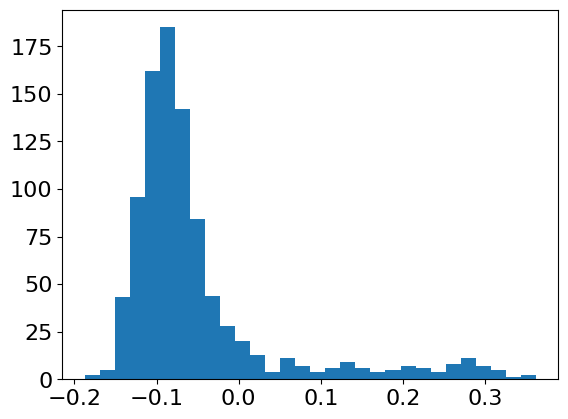

In [6]:
plt.hist(match_df['S(Gini, M20)'], bins=30)
plt.show()

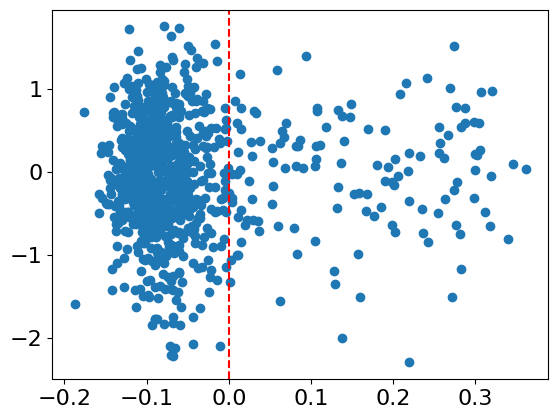

In [8]:
plt.scatter(match_df['S(Gini, M20)'], match_df['LOGSFR_2COMP'])
plt.axvline(x=0, color='r', linestyle='--')
plt.show()